# Bootstrapping

## 1. Betting on $242M in house purchases

- In 2018, Zillow entered the iBuying market with **Zillow Offers**: it bought homes at prices based on its own price-prediction model, fixed them up, and resold them
- In November 2021 it shut the business down, announced a loss of $421 million, and laid off about a quarter of its staff
- Zillow's CEO: the **unpredictability in forecasting home prices "far exceeds what we anticipated"**
- In this spirit, we are going to explore the uncertainty of estimates from a simple linear model of housing prices. You'll see that in this example, **bootstrapping** allows us to make a good decision almost all of the time.

**Today you're a real estate investor.** decide whether to buy twelve batches of houses in Ames, Iowa. Each deal is 100 houses of one size in one neighborhood, bought at a fixed cost per house and resold at the market price.

| Deal | Neighborhood | Size (sq ft) | Cost per house | | Deal | Neighborhood | Size (sq ft) | Cost per house |
|---|---|---|---|---|---|---|---|---|
| A | Gilbert | 1,600 | \$170,000 | | G | North Ames | 2,300 | \$210,000 |
| B | Old Town | 2,200 | \$176,000 | | H | Gilbert | 2,300 | \$249,000 |
| C | College Creek | 2,000 | \$201,000 | | I | Crawford | 1,600 | \$200,000 |
| D | Northridge Heights | 2,600 | \$445,000 | | J | Northwest Ames | 2,300 | \$187,000 |
| E | Northridge Heights | 1,800 | \$263,000 | | K | Edwards | 1,200 | \$100,000 |
| F | Somerset | 1,600 | \$200,000 | | L | Mitchell | 1,900 | \$200,000 |

- **BUY** earns 100 × (true price − cost), so you gain \$1 million for every \$10,000 per house the true price is above the cost, and lose \$1 million for every \$10,000 it is below
- **2** (double) buys 200 houses instead of 100, so it doubles the gain or the loss. Higher risk, higher reward
- **SKIP** earns \$0
- You bet twice (Round 1 and Round 2). Highest total wins a prize! (The stakes aren't as high as millions of dollars, but the stakes are cake!)

For each deal you get 30 **comps** (comparable sales: recent sales of similar houses nearby) from 2006 to 2010. Everyone gets a different 30. The code on your slip unlocks yours. The true prices stay locked until the end.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bootstrap_game import *

MY_CODE = "WRZR-QE6J" # TODO: change to the analyst code on your slip

my_comps = unlock_comps(MY_CODE)
my_comps['A'].head() # your first five Deal A comps (of 30)

,area,price,year_sold,month_sold
0,1664,172400,2006,1
1,1515,179000,2008,7
2,1746,198444,2007,6
3,1492,185101,2006,10
4,1746,377500,2009,10


### 1.1 From Comps to a Prediction
- We are trying to decide whether to buy a house based on the **predicted sales price** compared to the cost in the table above
- For each deal, fit a line $\hat y = \hat\alpha + \hat\beta x$ to your 30 comps, where $x$ is living area and $y$ is sale price:
$$
\hat{\beta} = \dfrac{(x-\bar{x})\cdot(y-\bar{y})}{(x-\bar{x})\cdot(x-\bar{x})}, \qquad \hat\alpha = \bar y - \hat\beta \bar x
$$
- The predicted price of a house with $x_0$ square feet is
$$
\hat y(x_0) = \bar y + \hat\beta\,(x_0 - \bar x)
$$
- Everyone uses the same formula (`predict(sales, sq_ft)`), which calculates the above estimate for slope ($\hat{\beta}$) and adds the mean ($\bar{y}$); only the comps differ

,deal,cost,my prediction,margin per house,if BUY (projected),scatter around line,house size percentile
A,"Gilbert, 1,600 sq ft","$170,000","$189,598","$19,598",+$2.0M,"$35,303",57%
B,"Old Town, 2,200 sq ft","$176,000","$209,298","$33,298",+$3.3M,"$39,959",93%
C,"College Creek, 2,000 sq ft","$201,000","$257,121","$56,121",+$5.6M,"$30,215",97%
D,"Northridge Heights, 2,600 sq ft","$445,000","$401,559","-$43,441",-$4.3M,"$47,746",93%
E,"Northridge Heights, 1,800 sq ft","$263,000","$310,983","$47,983",+$4.8M,"$74,052",40%
F,"Somerset, 1,600 sq ft","$200,000","$229,832","$29,832",+$3.0M,"$31,634",60%
G,"North Ames, 2,300 sq ft","$210,000","$184,684","-$25,316",-$2.5M,"$28,357",97%
H,"Gilbert, 2,300 sq ft","$249,000","$228,467","-$20,533",-$2.1M,"$17,196",100%
I,"Crawford, 1,600 sq ft","$200,000","$177,526","-$22,474",-$2.2M,"$33,142",20%
J,"Northwest Ames, 2,300 sq ft","$187,000","$234,005","$47,005",+$4.7M,"$25,108",87%


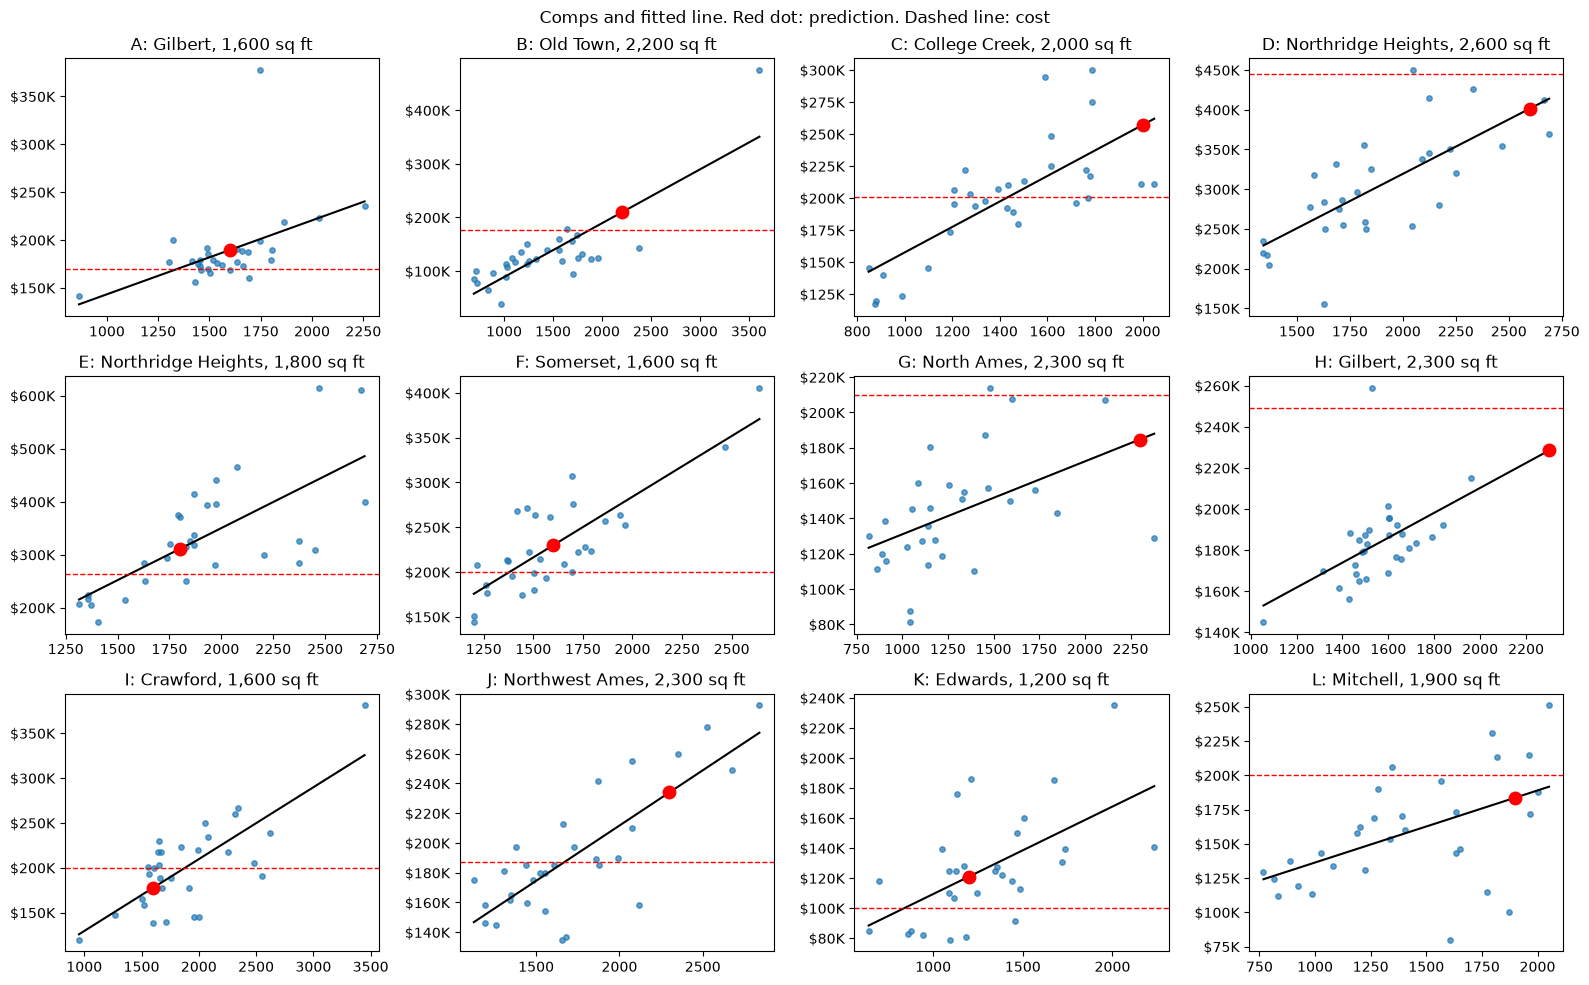

In [2]:
my_pred = show_deals(my_comps) # my_pred: a Series of my 12 predicted prices, indexed 'A'..'L'

#### Optional: calculate something before you bet

You'll only have a couple of minutes. These are the objects you can use:

| Name | What it is | Example |
|---|---|---|
| `my_pred` | pandas Series of your predicted prices, indexed by deal letter `'A'` to `'L'` | `my_pred['D']` |
| `DEALS` | pandas DataFrame, one row per deal (index `'A'` to `'L'`), columns `name`, `sq_ft`, `cost` | `DEALS.loc['D', 'cost']` |
| `my_comps` | dict from deal letter to a DataFrame of your 30 comps, columns `area` and `price` | `my_comps['D']['price']` |
| `predict(sales, sq_ft)` | the prediction formula above, for any set of sales | `predict(my_comps['D'], 2600)` |

`my_pred` looks like this (made-up numbers):

```
A    187588.711490
B    148224.869004
C    278901.114394
D    414796.315057
E    196343.316956
F    132356.470611
G    194989.625455
H    230852.711270
I    146006.590435
J    121487.947476
K    175219.566059
L    283790.122267
dtype: float64
```

`my_pred` and `DEALS['cost']` have the same index, so arithmetic matches up deal by deal:

```python
my_pred - DEALS['cost']                                           # margin per house for each deal
my_comps['D']['price'].std()                                      # SD of your Deal D comp prices
pd.Series({d: my_comps[d]['price'].std() for d in DEALS.index})   # same, for every deal
```

To bet using your own rule, make a True/False Series (True means buy) and convert it to letters:

```python
my_rule = (my_pred - DEALS['cost']) > 15_000         # example: buy if the margin is over $15,000
my_letters = ' '.join(np.where(my_rule, 'B', 'S'))   # a string like 'B B S B S S B S B B S S'
```
Then set `ROUND_1 = my_letters` below.

In [3]:
# Scratch space
my_pred

A    189598.321782
B    209297.938532
C    257121.201960
D    401559.347203
E    310982.736983
F    229832.304382
G    184684.063252
H    228466.870316
I    177526.348103
J    234005.149568
K    121041.578660
L    183650.626076
dtype: float64

### 1.2 Round 1
Pick a strategy, or type your own twelve letters (B, 2, or S, one per deal, A to L).

| Strategy | Rule |
|---|---|
| `"model"` | Buy whenever my prediction is above the cost |
| `"cushion"` | Buy only if my prediction beats the cost by at least `CUSHION` dollars (you choose the cushion) |
| `"middle"` | Buy only if my prediction beats the cost and the house size is inside the IQR of my comps (between the 25th and 75th percentile; see "house size percentile" in the table) |

After you pick, you can double any deal you're confident about: `round_1 = double(round_1, 'C')` buys 200 houses in Deal C. List several letters to double several deals.

In [9]:
ROUND_1 = "".join(["S", "S", "2", "S", "S", "S", "S", "S", "S", "2", "B", "S"]) # TODO: fill in. "model", "cushion", "middle", your own 12 letters, or my_letters
CUSHION = 0 # only used by "cushion"; set a value if using this strategy

round_1 = make_bets(ROUND_1, my_comps, my_pred)
# round_1 = double(round_1, 'C')   # optional: buy 200 houses in any deals you're confident about
show_bets(round_1, 'Round 1')

Round 1:  A=S  B=S  C=2x  D=S  E=S  F=S  G=S  H=S  I=S  J=2x  K=B  L=S


<div class="alert alert-warning">Write your name and your buys on an index card, including any double buys. Make sure you run the code cell above, setting the round_1 variable to your buys. </div>

### 1.3 Focus on Deal D
<div class="alert alert-warning"> Put a dot on the board at your Deal D prediction (in the $10k box it falls in). The line at $445,000 is the cost. </div>

<div class="alert alert-info">

**Question:** We all used the same formula on the same neighborhood. Why don't the dots agree? If the company picks one of us at random, what's the chance it buys Deal D?

</div>

### 1.4 What the Dots Tell Us
Should the company buy Deal D? The dots answer this in three steps.

**1. Where is the center?**
- The mean of the dots estimates the center of the sampling distribution, which is close to the true price:
$$
\bar{y} = \frac{1}{30}\sum_{k=1}^{30} \hat y_k
$$
- The gap between the center and the cost is $\bar{y} - 445{,}000$

**2. Can one analyst tell?**
- The SD of the dots is how far a single analyst's estimate typically lands from the center. This is the **standard error** of one prediction:
$$
s = \sqrt{\frac{1}{30-1}\sum_{k=1}^{30} \left(\hat y_k - \bar{y}\right)^2}
$$
- The $30 - 1$ instead of $30$ is **Bessel's correction**. The deviations are measured from $\bar{y}$, which comes from these same 30 dots, so they are slightly too small on average; dividing by $n - 1$ instead of $n$ corrects for that
- Compare the gap to $s$. If the gap is smaller than $s$, one analyst's error is bigger than the thing they're trying to detect

**3. Can the whole class tell?**
- The average of 30 analysts is off by only about $s/\sqrt{30}$ (week 2: an average of $n$ values varies by about $\sigma/\sqrt{n}$)
- Is \$445,000 inside $\bar{y} \pm 2s/\sqrt{30}$?

On the board, use the box midpoints $m_j$ and the number of dots in each box $n_j$:
$$
\bar{y} \approx \frac{1}{30}\sum_j n_j m_j, \qquad s \approx \sqrt{\frac{1}{29}\sum_j n_j \left(m_j - \bar{y}\right)^2}
$$

<div class="alert alert-info">

**Question:** Based on the dots, should the company buy Deal D? Could any one of us have answered that from our own 30 comps, without the other 29 dots?

</div>


## 2. IID Sequences and Sampling Distribution

### 2.1 Your Prediction Is an Estimator
- Your Deal D prediction comes from a fixed rule (fit a line to 30 comps, plug in 2,600 sq ft) applied to a random sample
- A different 30 comps gives a different prediction, so the prediction is a random variable
- It is a **statistic** (a function of the sample, defined below) that we use to estimate one particular unknown number: the true average price of a 2,600 sq ft house in Northridge Heights. A statistic used this way is called an **estimator**. Every estimator is a statistic; not every statistic is an estimator (for example, the largest price among your comps isn't trying to estimate anything in particular)
- The number you got from your 30 comps is an **estimate**. The dots on the board are 30 estimates from the same estimator

### 2.2 Statistics
- A **statistic** $S$ is any function of the sample data, like the sample mean or regression coefficients or $R^2$ or a prediction
- They are themselves random variables, mapping the underlying probability space associated with the data into numbers
- When the data are IID, how does this quantity behave?
- We call the density/distribution of a statistic its **sampling distribution**

### 2.3 Independent and Identically Distributed Sequences (iid)
- A fundamental concept in probability and statistics is the abstract idea of running an "experiment" over and over, and computing statistics for the results
- Let $x_1$ be the result of the first experiment, $x_2$ the result of the second, and so on
- Assume that the draws $x_1, x_2, ...$ 
  - are **identically distributed**: They are all drawn from the same distribution function and all have the same mean $\mu$ and variance $\sigma^2$
  - are **independent**: The outcome of draw $x_n$ doesn't affect the outcome of any draw $x_m$, $m \neq n$ (in the sense of conditioning)

### 2.4 Why Independence Matters
- Each prediction assumes its 30 comps are independent draws from the neighborhood
- If they weren't (for example, 30 sales from one hot month that all ran high), 30 comps would tell you less than 30 independent sales, and the dots would spread out more
- The autoregressive process below is a simple model of values that depend on the previous one

### 2.5 Example: Not iid
- To appreciate iid, let's look at something that is not iid
- An **autoregressive-1 process** is 
$$
y_{t} = \alpha + \rho y_{t-1} + \sigma \varepsilon_t
$$
where $\varepsilon_t$ is iid with mean 0 and standard deviation 1
- An AR-$K$ process uses more lagged values:
$$
y_{t} = \alpha + \sum_{k=1}^K \rho_k y_{t-k} + \sigma \varepsilon_t
$$

### 2.6 Autocovariance of the AR1
$$
\begin{alignat*}{2}
\text{cov}(Y_{t-1}, Y_{t}) &=& \text{cov}(Y_{t-1}, \alpha + \rho Y_{t-1} + \sigma \varepsilon_{t} )
\\
&=& \text{cov}(Y_{t-1}, \alpha) + \text{cov}(Y_{t-1},\rho Y_{t-1}) + \text{cov}(Y_{t-1},\sigma \varepsilon_{t} )\\
&=& 0 + \rho \text{cov}(Y_{t-1},Y_{t-1})+ 0 \\
&=& \rho \mathbb{V}[Y_{t-1}]
\end{alignat*}
$$
- This sequence is independent only if $\rho=0$, and then we call this a **white noise process**

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def ar1sim(rho=0.8):
    rng = np.random.default_rng(100)

    # Parameters
    T = 200
    alpha = 1.0
    sigma = 1.0
    initial = 10

    # Simulate innovations
    eps = rng.normal(size=T + initial)

    # Simulate AR(1)
    y = np.zeros(T + initial)
    for t in range(1, T + initial):
        y[t] = alpha + rho * y[t - 1] + sigma * eps[t]
    y = y[initial:]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Time series plot
    ax[0].plot(y)
    ax[0].set_xlabel("t")
    ax[0].set_ylabel(r"$y_t$")
    ax[0].set_title(
        rf"AR(1): $\alpha={alpha}$, $\rho={rho}$, $\sigma={sigma}$"
    )

    # Lag plot
    ax[1].scatter(y[:-1], y[1:], alpha=0.6)
    ax[1].set_xlabel(r"$y_t$")
    ax[1].set_ylabel(r"$y_{t+1}$")
    ax[1].set_title(r"$y_{t+1}$ versus $y_t$")

    plt.tight_layout()
    plt.show()

In [ ]:
ar1sim(.95)

In [ ]:
ar1sim(-.75)

In [ ]:
ar1sim(0.0)

- The same two plots for your Deal D comps, put in the order the houses were sold (the order we drew them in is random, so it can't show anything)

In [ ]:
lag_plot(my_comps['D'], 'My Deal D comps')

- With $\rho = 0.95$ the lag plot is close to a line; with $\rho = 0$ it's a cloud
- In sale order, your comps look like the $\rho = 0$ case: the correlation between one sale and the next is close to 0, so a high price doesn't predict a high price on the next sale
- This is a check on the market, not just on how we sampled. Real comps are usually the most recent sales, so if neighboring sales did move together, 30 recent comps would be worth less than 30 independent ones

### 2.7 Example: Linear Regression
- Suppose the model is
$$
y_i = 1.0 - 2.0 \times x_i + \sigma \varepsilon_i
$$
where $\mathbb{E}[\varepsilon_i|x_i]=0$ and $\mathbb{E}[\varepsilon_i^2|x_i]=1$
- The slope coefficient is
$$
\hat{\beta} = \dfrac{(x-\bar{x})\cdot(y-\bar{y})}{(x-\bar{x})\cdot(x-\bar{x})} \approx \dfrac{\text{cov}(X,Y)}{\text{var}(X)}
$$

- (How much x and y move together)/(how much x moves)
- You can do the same procedure with multiple linear regression, using
$$
\hat{\beta} = [ (X-\bar{X})^{\top}(X-\bar{X}) ]^{-1} [(X-\bar{X})^{\top}(Y-\bar{Y})] \approx C_{X,X}^{-1} C_{X,Y}
$$ 

- The board has 30 dots. When we know the true model (here $\beta = -2$), we can draw as many samples of 30 as we want and see the whole sampling distribution
- For Deal D, I did the same thing with the real data. In this game, the "true price" is the prediction from every sale in that neighborhood in the data file. We're treating the whole file as the market, so we can draw fresh sets of 30 comps from it as often as we like

In [11]:
def gen_data(N = 10_000):
    ## Parameters
    a = 1.0
    b = -2.0
    cov = np.array( [[5.0, 0], [0, 7.0]])
    ## Generate shocks and explanatory variable
    draws = rng.multivariate_normal( mean = np.array([10,0]), 
                                    cov = cov, size = N )
    X = draws[:,0]
    eps = draws[:,1]
    y = a + b * X + eps
    ## Send to dataframe
    df = pd.DataFrame( {'X':X, 'y':y })
    return df

def slr(x,y):
    w_x = x - x.mean()
    w_y = y - y.mean()
    beta_hat = np.inner(w_x, w_y) / np.inner(w_x, w_x)
    return beta_hat

In [12]:
rng = np.random.default_rng(100)
R = 5_000
N = 30  # same size as your comps
results = []
for i in range(R):
    df_i = gen_data(N)
    beta_i = slr( df_i['X'], df_i['y'])
    results.append(beta_i)
results = np.array(results)

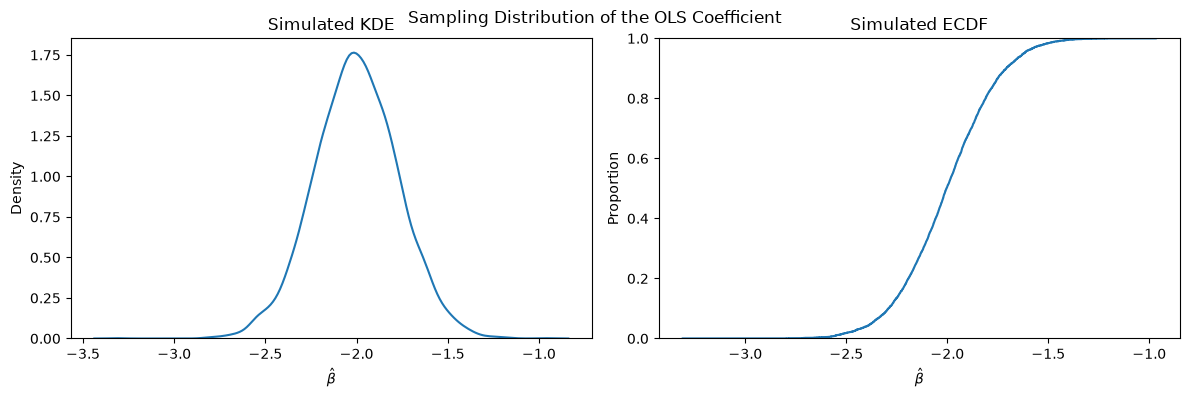

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# KDE
sns.kdeplot(results, ax=ax[0])
ax[0].set_xlabel(r"$\hat{\beta}$")
ax[0].set_title("Simulated KDE")
# ECDF
sns.ecdfplot(results, ax=ax[1])
ax[1].set_xlabel(r"$\hat{\beta}$")
ax[1].set_title("Simulated ECDF")
plt.tight_layout()
fig.suptitle('Sampling Distribution of the OLS Coefficient')
plt.show()

### 2.8 Sampling Distribution
- Asymptotic statistics is generally about deriving the distribution of a statistic as the sample size gets large
- The Central Limit Theorem says, roughly, that the above picture should be a normal distribution with a mean around the truth, and a variance tending towards zero
- This was very popular until about 2005, when computers became powerful enough to use data-driven approaches to modeling the sampling distribution (jackknife, cross validation, bootstrap)

- For our Deal D prediction with $n = 30$ comps, the sampling distribution is close to normal, with a slight right skew from a few expensive houses. With $n = 100$ the skew is mostly gone
- The CLT gives the shape (normal) and the center (the true value), but not the width. We still need the standard error, and with one sample we have to estimate it. That is what the bootstrap is for


## 3. The Bootstrap

### 3.1 Bootstrapping
- As data scientists, we typically can't run more experiments or get more observations: The data are often all we get
- How can we "simulate" the experiment many times, to learn about the sampling distribution of our statistic/parameters/predictions?
- Big Idea: **If the data are iid** and **sampled at random** from the underlying data generation process, then we can **resample (with replacement)** our data to simulate drawing a new sample from the original data generating process

- For Deal D, the board needed 30 of us, and the simulation needed every sale in the neighborhood
- An actual analyst has one set of 30 comps. Can you estimate the spread of the dots from those alone?

### 3.2 Bootstrapping the Sampling Distribution
- Fix a bootstrap replication value $R$.

1. For $t$ in $1, ..., R$,
    - Drawn a sample of $n$ observations from your data with replacement, $D_t$
    - Compute the statistic for this sample, $\hat{S}_t = S(D_t)$
2. The collection $[\hat{S}_1, ..., \hat{S}_R]$ then approximates the sampling distribution of $\hat{S}$

Using the collection $[\hat{S}_1, ..., \hat{S}_R]$, we can:
- Compute the ECDF, which is an estimator of the sampling distribution
- Compute the KDE, which is an estimator of the sampling density
- Compute the standard deviation, which is the standard error of $\hat{S}$


### 3.3 The Variation in Data
- As it turns out, there is an huge amount of variation in your data
- There are $10^{80}$ atoms in the universe, $10^{11}$ stars in an average galaxy, and $10^{12}$ galaxies in the observable universe; these are inconceivably large numbers
- If you have a dataset with $N$ rows, how many ways are there to draw the first replicate? $N$. The second? $N$. And so on. 
- There are $N^N$ ways to resample your data, with replacement.
- If $N=100$, there are $100^{100}$ ways to resample it, greater than the number of stars in an average galaxy, the number of galaxies in the observable universe, and even the number of atoms
- It is not credible that we can exhaust the number of ways to resample a dataset, even on the most powerful computers we have, with even moderately large datasets

### 3.4 Other Kinds of Bootstrap

- This version (non-parametric bootstrap) is appropriate if the data are IID; otherwise there are other flavors (block bootstrap, wild bootstrap) to account for spatial or temporal correlation
- For now, the KDE/ECDF plots are the answer: We can quantify the uncertainty associated with our estimates

### 3.5 Bootstrap Your Comps
- Resample your 30 comps with replacement, predict again, and repeat 1,000 times, for every deal (takes a few seconds)

,deal,cost,my prediction,bootstrap SD,my 95% interval,cost vs. interval
A,"Gilbert, 1,600","$170,000","$189,598","$6,674","($179,194, $204,430)",interval above cost
B,"Old Town, 2,200","$176,000","$209,298","$31,618","($144,059, $244,466)",cost inside interval
C,"College Creek, 2,000","$201,000","$257,121","$15,817","($231,761, $293,010)",interval above cost
D,"Northridge Heights, 2,600","$445,000","$401,559","$17,703","($372,223, $440,837)",interval below cost
E,"Northridge Heights, 1,800","$263,000","$310,983","$10,838","($291,382, $332,963)",interval above cost
F,"Somerset, 1,600","$200,000","$229,832","$6,071","($218,871, $242,691)",interval above cost
G,"North Ames, 2,300","$210,000","$184,684","$23,079","($150,160, $239,222)",cost inside interval
H,"Gilbert, 2,300","$249,000","$228,467","$8,946","($207,906, $243,445)",interval below cost
I,"Crawford, 1,600","$200,000","$177,526","$6,733","($165,258, $191,572)",interval below cost
J,"Northwest Ames, 2,300","$187,000","$234,005","$9,111","($212,072, $247,882)",interval above cost


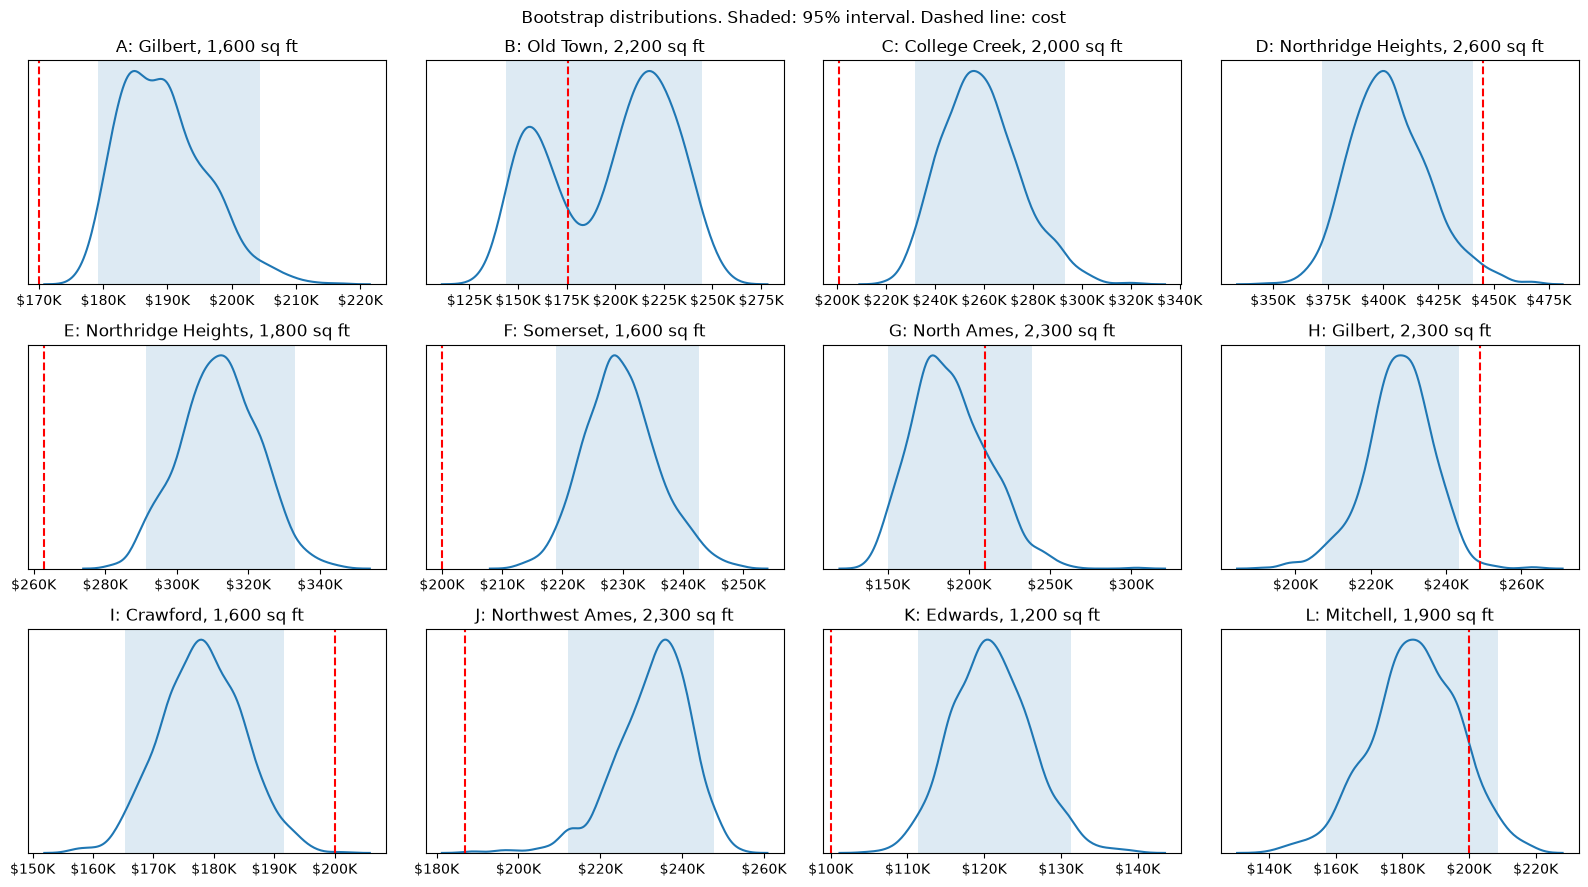

In [14]:
R = 1000
my_reps = {}
for d in DEALS.index:
    reps = []
    for r in range(R):
        comps_r = my_comps[d].sample( frac = 1.0, replace = True )
        reps.append( predict(comps_r, DEALS.loc[d, 'sq_ft']) )
    my_reps[d] = np.array(reps)

my_lo, my_hi = show_intervals(my_reps, my_pred)

- Compare your Deal D bootstrap SD (in the table) to the spread of the dots on the board

- Each bootstrap distribution is centered on that student's own prediction, so the centers differ
- The spreads are in the same range as the spread of the true sampling distribution. They aren't exact, since each one comes from only 30 comps
- For a buy/skip decision, the spread is what you need

#### Why the bootstrap gets the spread about right
- The spread of the sampling distribution depends on how spread out the population is, not on where it is centered. For a sample mean it is $\sigma/\sqrt{n}$
- Resampling your data is like sampling from a population whose SD is your sample's SD, $\hat\sigma$, so the bootstrap spread is about $\hat\sigma/\sqrt{n}$. A sample whose center is off can still have about the right spread
- As $n$ grows, $\hat\sigma$ gets close to $\sigma$, so the bootstrap spread gets close to the true spread. With $n = 30$ it is a noisy estimate: one student's bootstrap SD can easily be off by a third
- The center does not improve this way. Your bootstrap distribution is always centered on your own estimate
- All of this assumes a random sample. If the sample is systematically biased (only the nicer streets, only one hot month), the bootstrap copies the bias and gives a tight interval around the wrong answer


### Aside: another example with a different statistic

The example below is based on the cardiac patient data we've seen before. Here we are building a regression model on heart rate to predict a cardiac arrest event. We'll resample the rows 5000 times to get a distribution of $\beta$.

The slr coefficient is: -0.008


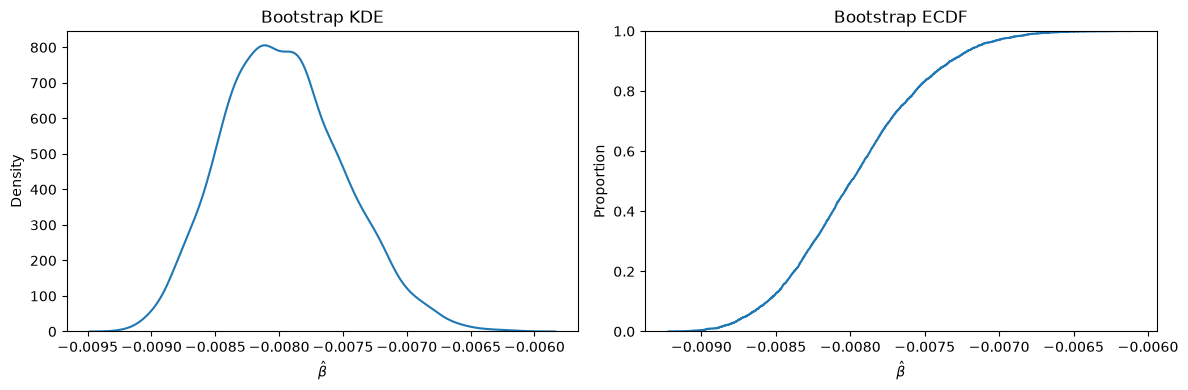

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/CardiacPatientData.csv')
df.head()

df = df.loc[:,['HR','Outcome']].dropna()
y = df['Outcome']
x = df['HR']

def slr(x,y):
    w_x = x - x.mean()
    w_y = y - y.mean()
    beta_hat = np.inner(w_x, w_y) / np.inner(w_x, w_x)
    return beta_hat

beta_hat = slr(x,y)
print(f'The slr coefficient is: {beta_hat:.3f}')

R = 5000
replications = []
for r in range(R):
    df_r = df.sample( frac = 1.0, replace = True )
    y_r = df_r['Outcome']
    x_r = df_r['HR']
    beta_r = slr(x_r, y_r)
    replications.append(beta_r)
replications = np.array(replications)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# KDE
sns.kdeplot(replications, ax=ax[0])
ax[0].set_xlabel(r"$\hat{\beta}$")
ax[0].set_title("Bootstrap KDE")
# ECDF
sns.ecdfplot(replications, ax=ax[1])
ax[1].set_xlabel(r"$\hat{\beta}$")
ax[1].set_title("Bootstrap ECDF")
plt.tight_layout()
plt.show()

## 4. Confidence Intervals and Round 2

### 4.1 Communicating Results
- The distribution of the replicates is an estimate of the sampling distribution; excellent
- The picture contains multitudes, but people often want a summary of the results in a parametric or numeric form that can more easily be understood
- We typically report an interval $(L,H)$ that includes 90/95/99% of our replicates, as a bound on what kinds of values we expect to estimate from this kind of process
- This is called a **confidence interval**

### 4.2 Percentile Bootstrap Confidence Intervals

- We typically focus on three cases: 
    - The 90% confidence interval is the .05 and .95 quantiles ($\alpha = .10$) of the sample $[\hat{S}_1, ..., \hat{S}_B]$
    - The 95% confidence interval is the .025 and .975 quantiles ($\alpha = .05$) of the sample $[\hat{S}_1, ..., \hat{S}_B]$
    - The 99% confidence interval is the .005 and .995 quantiles ($\alpha = .01$) of the sample $[\hat{S}_1, ..., \hat{S}_B]$

- In general, the parameter $\alpha$ is typically .10, .05, or .01, called the **(statistical) level**. The **two-tailed $(1-\alpha)$-confidence interval** is:
    1. Find the $\alpha/2$ and $1-\alpha/2$ quantiles of the bootstrap sample $[\hat{S}_1, ..., \hat{S}_B]$, $q_{\alpha/2}$ and $q_{1-\alpha/2}$
    2. Report the confidence interval as the quantiles $(q_{\alpha/2}, q_{1-\alpha/2})$

### 4.3 Hypothesis Testing
- Suppose you had a **hypothesized value** that you were particularly interested in; very often, it's zero, but it could be anything
- You might ask, "Is my hypothesized value in the confidence interval?" This is the **null hypothesis**
- The **alternative hypothesis** is that the hypothesized value is not in the confidence interval
- This is a statistical test: Are my results consistent with a null that $S=0$ (or whatever), or with the alternative that $S \neq 0$ (or whatever)?
- The tricky part of this is that we typically want to **reject the null** and find evidence that $S\neq 0$ (or whatever): We typically want to reject the null that the expensive cancer drug does nothing, in favor of the alternative that the effect size is relatively large

### 4.4 Round 2
- For each deal, the hypothesized value is the cost. Is it inside your 95% interval?
- New strategy: `"interval"`, which buys only if your whole 95% interval is above the cost. You can also reuse a Round 1 strategy or type your own letters
- You can double deals again with `double(round_2, ...)`


In [16]:
ROUND_2 = ROUND_1            # "interval", "model", "cushion", "middle", or your own 12 letters

round_2 = make_bets(ROUND_2, my_comps, my_pred, cushion=CUSHION, lo=my_lo)
# round_2 = double(round_2, 'C')   # optional: buy 200 houses in any deals you're confident about
show_bets(round_1, 'Round 1')
show_bets(round_2, 'Round 2')

Round 1:  A=S  B=S  C=2x  D=S  E=S  F=S  G=S  H=S  I=S  J=2x  K=B  L=S
Round 2:  A=S  B=S  C=2x  D=S  E=S  F=S  G=S  H=S  I=S  J=2x  K=B  L=S


### 4.5 Interpreting the Bootstrap and CI

- This is literally, "If you repeat this statistical procedure many times, 90/95/99% of the intervals you construct will contain the true value of $S$"
- This is not, "The true value of $S$ is in this interval with probability .90/.95/.99" because the true value $S$ is a fixed number, so there's nothing random to it; S is inside the interval or it isn't. 
- Indeed, the true value either **is** or **is not** in the interval: We are simply quantifying how much sampling variation there is in our measurement tools
- Frequentist methods are typically $\text{pr}[\text{data}|\text{hypothesis}]$, while Bayesian methods are $\text{pr}[\text{hypothesis}|\text{data}]$
- This is a statistical reliability procedure, not a truth machine
- A coin analogy: before a flip, the probability of heads is 0.5. After it lands under your hand, it is heads or tails; you just don't know which. The 95% describes the procedure before you run it
- An unlucky sample gives an interval that misses. The 95% is about the method across many samples, not about your particular interval


## 5. The Reveal
- Enter the reveal code once everyone has placed Round 2. The cell scores both rounds and plots your Deal D bootstrap against Deal D's true sampling distribution
- In this game, the "true price" is the prediction from every sale in that neighborhood in the data file. We're treating the whole file as the market. The real market value of these houses is still unknown; the file is the best stand-in we have

,deal,cost,true price,winner?,if BUY (100),round 1 bet,round 1 call,round 2 bet,round 2 call,truth in my interval?
deal,,,,,,,,,,
A,"Gilbert, 1,600","$170,000","$189,079",winner,+$1.9M,S +$0.0M,WRONG (skipped a winner),S +$0.0M,WRONG (skipped a winner),yes
B,"Old Town, 2,200","$176,000","$168,067",loser,-$0.8M,S +$0.0M,right (skipped a loser),S +$0.0M,right (skipped a loser),yes
C,"College Creek, 2,000","$201,000","$255,219",winner,+$5.4M,2 +$10.8M,right (bought a winner),2 +$10.8M,right (bought a winner),yes
D,"Northridge Heights, 2,600","$445,000","$429,679",loser,-$1.5M,S +$0.0M,right (skipped a loser),S +$0.0M,right (skipped a loser),yes
E,"Northridge Heights, 1,800","$263,000","$298,657",winner,+$3.6M,S +$0.0M,WRONG (skipped a winner),S +$0.0M,WRONG (skipped a winner),yes
F,"Somerset, 1,600","$200,000","$229,113",winner,+$2.9M,S +$0.0M,WRONG (skipped a winner),S +$0.0M,WRONG (skipped a winner),yes
G,"North Ames, 2,300","$210,000","$200,142",loser,-$1.0M,S +$0.0M,right (skipped a loser),S +$0.0M,right (skipped a loser),yes
H,"Gilbert, 2,300","$249,000","$241,588",loser,-$0.7M,S +$0.0M,right (skipped a loser),S +$0.0M,right (skipped a loser),yes
I,"Crawford, 1,600","$200,000","$196,263",loser,-$0.4M,S +$0.0M,right (skipped a loser),S +$0.0M,right (skipped a loser),no


Round 1: 9 of 12 right; wrong: skipped winners A, E, F
Round 2: 9 of 12 right; wrong: skipped winners A, E, F

Round 1 total: +$21.8M      (best possible +$40.9M)
Round 2 total: +$21.8M      (best possible +$40.9M)
Both rounds:   +$43.5M
Intervals containing the true price: 11 of 12


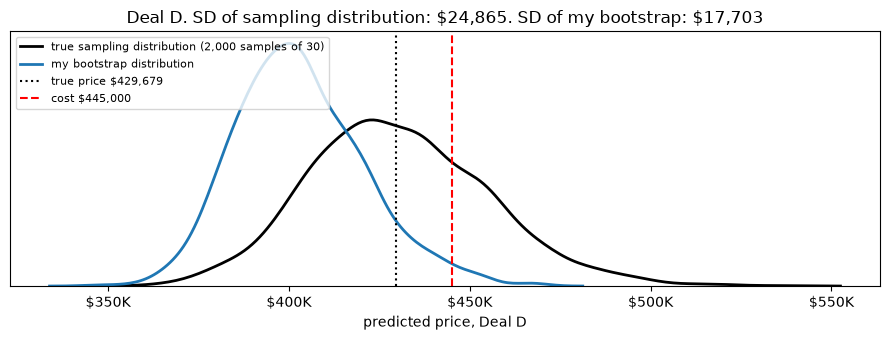

In [17]:
REVEAL_CODE = "F72A-VRQC"      # the code I will announce

truth = reveal(REVEAL_CODE, round_1, round_2, my_lo, my_hi, my_reps)

<div class="alert alert-warning">Write your strategies and total for each round on your index card, and how many of your twelve intervals contained the true price</div>

- Suppose 100 analysts each got their own 30 Northridge Heights comps and built a 95% bootstrap interval for Deal D. About 95 of the intervals should contain the true price
- Each analyst sees only their own interval and can't tell whether it's one of the ones that missed

### 5.1 What Happened
- Some deals made money: Their intervals were entirely above the cost for almost everyone
- Some deals lost money: The cost was inside almost everyone's interval, but in Round 1 some of you bought them anyway, depending on which comps you got
- A single cushion doesn't work for every deal: bootstrap SDs range from about \$4,000 (Gilbert, Deal A) to about \$25,000 (Northridge Heights, Deal D)
- **The bootstrap doesn't make the predictions more accurate. It tells you how far off each one could be, deal by deal**